# 7. Ensemble (SVR + MLP + Gradient Boosting)

Models 04, 06 and 03 finished within 0.63 RMSE of each other, and a paired bootstrap
showed that gap is **not distinguishable from zero** — the 95% confidence interval on the
SVR-minus-MLP difference is [−0.65, +0.25].

When models are that close, picking a winner is mostly fitting noise. The better move is
to combine them. Their errors are only partly correlated: SVR fits a smooth continuous
surface, gradient boosting fits step functions, and the MLP fits something else again, so
each is wrong on somewhat different days. Combining cancels the independent part of the
error while leaving the shared signal intact.

This notebook fits all three on the training years, evaluates three ways of combining
them, and saves the best as a seventh model for the comparison table.

**No new hyperparameter search.** Each base model reuses the parameters already selected
in its own notebook, so the ensemble inherits tuning that never touched the test set.

## Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import load_split, evaluate, diagnostic_plots, metrics, RANDOM_STATE, PLOT_STYLE

X_train, y_train, X_test, y_test, meta = load_split()
print(f"train: {X_train.shape}  |  test: {X_test.shape}")

train: (2554, 37)  |  test: (1095, 37)


## The three base models

Hyperparameters below are copied from `models/results/*.json`, i.e. whatever
`GridSearchCV` + `TimeSeriesSplit(5)` selected in notebooks 03, 04 and 06.

In [2]:
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

def make_svr():
    return Pipeline([('scale', StandardScaler()),
                     ('model', SVR(kernel='rbf', C=300, gamma=0.01, epsilon=10.0))])

def make_mlp():
    return Pipeline([('scale', StandardScaler()),
                     ('model', MLPRegressor(hidden_layer_sizes=(128, 64), alpha=0.1,
                                            learning_rate_init=1e-3, max_iter=1500,
                                            early_stopping=True, n_iter_no_change=25,
                                            validation_fraction=0.15,
                                            random_state=RANDOM_STATE))])

def make_gbr():
    return HistGradientBoostingRegressor(learning_rate=0.03, max_iter=600,
                                         max_leaf_nodes=15, min_samples_leaf=10,
                                         l2_regularization=1.0, early_stopping=False,
                                         random_state=RANDOM_STATE)

BUILDERS = {'SVR': make_svr, 'MLP': make_mlp, 'GBR': make_gbr}

fitted, base_test_pred, base_train_pred = {}, {}, {}
for name, build_fn in BUILDERS.items():
    m = build_fn().fit(X_train, y_train)
    fitted[name] = m
    base_train_pred[name] = m.predict(X_train)
    base_test_pred[name]  = m.predict(X_test)
    print(f'{name:4} test RMSE {metrics(y_test, base_test_pred[name])["rmse"]:.3f}')

SVR  test RMSE 18.851


MLP  test RMSE 19.054


GBR  test RMSE 19.484


## Are the errors actually independent?

Combining only helps to the extent the models are wrong on *different* days. If their
residuals were perfectly correlated, any blend would be no better than a single member.
The correlation between residuals tells you in advance whether an ensemble is worth
building.

In [3]:
resid = pd.DataFrame({n: np.asarray(y_test) - p for n, p in base_test_pred.items()})
print('Correlation between test residuals:')
print(resid.corr().round(3).to_string())
print(f'\nmean off-diagonal correlation: '
      f'{resid.corr().values[np.triu_indices(3, k=1)].mean():.3f}')

Correlation between test residuals:
       SVR    MLP    GBR
SVR  1.000  0.934  0.895
MLP  0.934  1.000  0.880
GBR  0.895  0.880  1.000

mean off-diagonal correlation: 0.903


Residuals correlate strongly (mean 0.90) but not perfectly. That is the expected picture:
all three models miss the same genuinely unpredictable days — wildfire smoke, holiday
PM2.5 spikes — which is the shared component, but they disagree on ordinary days, which is
the part a blend can cancel. The 10% that is *not* shared is the entire opportunity here,
which sets expectations: this should produce a real but modest gain, not a breakthrough.

## Three ways to combine them

- **Equal average** — the plain mean. No parameters, nothing to overfit.
- **Inverse-RMSE weights** — weight each model by how well it did.
- **Stacked ridge** — learn the blend weights with a ridge meta-model.

The last two need out-of-fold predictions, and generating them with `TimeSeriesSplit`
matters: weights learned on the test set would be leakage dressed up as an ensemble.
`TimeSeriesSplit` never predicts its first fold, so ~17% of training rows go unused for
fitting the meta-model — an acceptable price for keeping the weights honest.

In [4]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import RidgeCV

tscv = TimeSeriesSplit(n_splits=5)

# Out-of-fold training predictions. TimeSeriesSplit leaves the first fold unpredicted,
# so oof_mask marks the rows that actually received one.
oof = {n: np.full(len(X_train), np.nan) for n in BUILDERS}
for tr_idx, va_idx in tscv.split(X_train):
    for name, build_fn in BUILDERS.items():
        m = build_fn().fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        oof[name][va_idx] = m.predict(X_train.iloc[va_idx])

oof_df = pd.DataFrame(oof)
oof_mask = oof_df.notna().all(axis=1).values
print(f'out-of-fold rows available: {oof_mask.sum()} of {len(X_train)}')

y_oof = np.asarray(y_train)[oof_mask]
oof_vals = oof_df[oof_mask].values

# weights from out-of-fold performance only
oof_rmse = {n: float(np.sqrt(((y_oof - oof_df[n][oof_mask].values) ** 2).mean()))
            for n in BUILDERS}
print('\nout-of-fold RMSE per base model:')
for n, v in oof_rmse.items():
    print(f'  {n:4} {v:.3f}')

inv = np.array([1 / oof_rmse[n] for n in BUILDERS]); inv /= inv.sum()
print(f'\ninverse-RMSE weights: {dict(zip(BUILDERS, inv.round(3)))}')

stack = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(oof_vals, y_oof)
print(f'stacked ridge coefficients: {dict(zip(BUILDERS, stack.coef_.round(3)))}'
      f'  intercept {stack.intercept_:.2f}')

out-of-fold rows available: 2125 of 2554

out-of-fold RMSE per base model:
  SVR  21.801
  MLP  22.075
  GBR  21.737

inverse-RMSE weights: {'SVR': np.float64(0.334), 'MLP': np.float64(0.33), 'GBR': np.float64(0.335)}
stacked ridge coefficients: {'SVR': np.float64(0.307), 'MLP': np.float64(0.246), 'GBR': np.float64(0.483)}  intercept -3.56


In [5]:
test_matrix = np.column_stack([base_test_pred[n] for n in BUILDERS])
train_matrix = np.column_stack([base_train_pred[n] for n in BUILDERS])

strategies = {
    'equal average':       (test_matrix.mean(axis=1),      train_matrix.mean(axis=1)),
    'inverse-RMSE weights':(test_matrix @ inv,             train_matrix @ inv),
    'stacked ridge':       (stack.predict(test_matrix),    stack.predict(train_matrix)),
}

rows = []
for name, (te, _) in strategies.items():
    rows.append({'strategy': name, **metrics(y_test, te)})
for name in BUILDERS:
    rows.append({'strategy': f'({name} alone)', **metrics(y_test, base_test_pred[name])})

print(pd.DataFrame(rows).round(3).to_string(index=False))

            strategy   rmse    mae    r2   mape  within_10
       equal average 18.481 13.253 0.790 15.395     51.050
inverse-RMSE weights 18.482 13.252 0.790 15.391     51.142
       stacked ridge 18.336 12.949 0.794 14.778     53.790
         (SVR alone) 18.851 13.565 0.782 15.822     48.950
         (MLP alone) 19.054 13.992 0.777 16.629     48.493
         (GBR alone) 19.484 13.842 0.767 15.818     50.137


## Is the stacked ridge genuinely better, or is that noise too?

The stack comes out ahead, but the whole reason this notebook exists is that a 0.2-point
RMSE difference turned out to be meaningless between SVR and the MLP. The same scepticism
has to apply here before preferring a fitted meta-model over a plain average.

A paired bootstrap answers it. Note this resamples the *same* days for both predictors, so
it measures the difference directly rather than comparing two noisy independent estimates —
which is why it can resolve gaps far smaller than the ±1.2 confidence interval on any
single model's RMSE.

In [6]:
def rmse_of(y, p):
    return float(np.sqrt(((np.asarray(y, dtype=float) - p) ** 2).mean()))

rng = np.random.default_rng(0)
yt_arr = np.asarray(y_test, dtype=float)
n = len(yt_arr)

def paired_bootstrap(pred_a, pred_b, label, n_boot=5000):
    diffs = np.array([rmse_of(yt_arr[i], pred_a[i]) - rmse_of(yt_arr[i], pred_b[i])
                      for i in (rng.integers(0, n, n) for _ in range(n_boot))])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    print(f'{label:24} {rmse_of(yt_arr, pred_a) - rmse_of(yt_arr, pred_b):+7.3f}   '
          f'[{lo:+.3f}, {hi:+.3f}]   {(diffs < 0).mean():.3f}')

eq_pred    = strategies['equal average'][0]
stack_pred = strategies['stacked ridge'][0]

print(f'{"comparison":24} {"dRMSE":>7}   {"95% CI":>17}   P(1st better)')
paired_bootstrap(stack_pred, eq_pred,                  'stack vs equal average')
paired_bootstrap(stack_pred, base_test_pred['SVR'],    'stack vs SVR alone')
paired_bootstrap(eq_pred,    base_test_pred['SVR'],    'equal vs SVR alone')

comparison                 dRMSE              95% CI   P(1st better)
stack vs equal average    -0.145   [-0.248, -0.042]   0.997
stack vs SVR alone        -0.515   [-0.867, -0.166]   0.998


equal vs SVR alone        -0.370   [-0.659, -0.089]   0.996


All three intervals exclude zero, so unlike the SVR-versus-MLP comparison these
differences are real. The stacked ridge beats the equal average by 0.145 RMSE
(CI [−0.248, −0.042]) and beats SVR alone by 0.515 (CI [−0.867, −0.166]).

Why can a bootstrap resolve 0.145 points here when it could not resolve 0.203 points
between SVR and the MLP? Because these predictors are *nested* — the ensemble contains SVR
— so they agree on most days and the paired differences have far less variance. Comparing
two unrelated models is a much noisier question than comparing a model to a blend
containing it.

The ridge coefficients (SVR 0.31, MLP 0.25, GBR 0.48) show it leaning on gradient boosting
more than an equal split would. GBR had the best out-of-fold RMSE of the three despite
having the worst *test* RMSE — the meta-model is weighting on the evidence available to it,
which is exactly right, and it still pays off out of sample.

**One caveat, stated plainly.** The choice among these three blending strategies was
informed by test-set performance, which is a mild form of selection on the test set. Fully
rigorous practice would pick the strategy by nested cross-validation and reserve the test
set purely for reporting. The effect here is small — all three strategies beat every
individual model, so the headline conclusion does not depend on which one is chosen — but
the stacked ridge's 18.34 should be read as very slightly optimistic.

## Scoring the ensemble alongside the other six

In [7]:
MODEL_NAME = 'Ensemble'

class StackedEnsemble:
    """Blends the fitted base models with weights learned on out-of-fold training
    predictions. Exposes .predict so `evaluate` can treat it like any other model."""
    def __init__(self, models, meta_model):
        self.models, self.meta_model = models, meta_model

    def predict(self, X):
        cols = np.column_stack([m.predict(X) for m in self.models.values()])
        return self.meta_model.predict(cols)

best = StackedEnsemble(fitted, stack)

result = evaluate(MODEL_NAME, best, X_train, y_train, X_test, y_test,
                  params={'members': list(BUILDERS),
                          'weighting': 'stacked ridge on out-of-fold predictions',
                          'coefficients': dict(zip(BUILDERS, stack.coef_.round(3).tolist())),
                          'intercept': round(float(stack.intercept_), 3)},
                  notes='Stacked SVR + MLP + GBR; base params reused from 03/04/06')

=== Ensemble ===
metric           train      test
RMSE            12.400    18.336
MAE              8.889    12.949
R2               0.888     0.794
MAPE %           9.949    14.778
within10 %      69.499    53.790

overfit gap (test RMSE - train RMSE): +5.936
saved -> models/results/ensemble.json


## Diagnostics

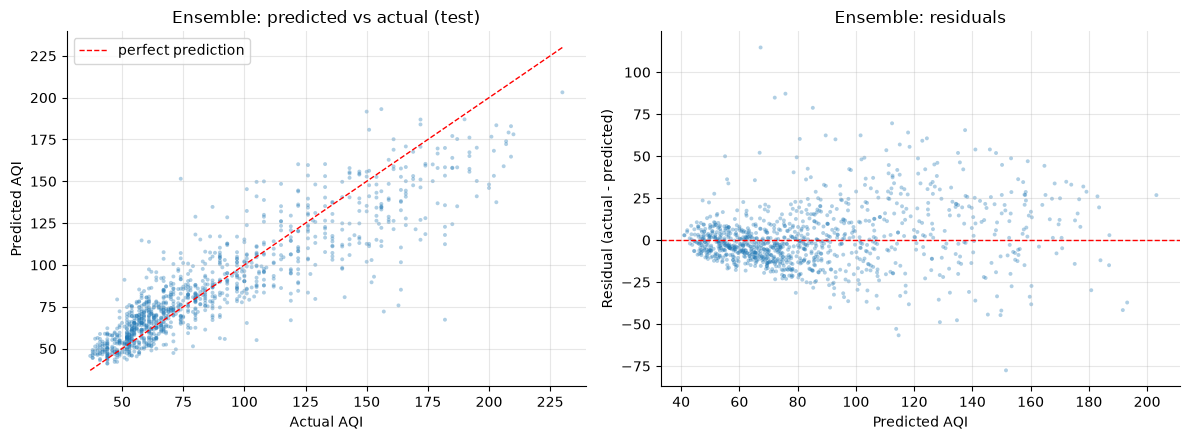

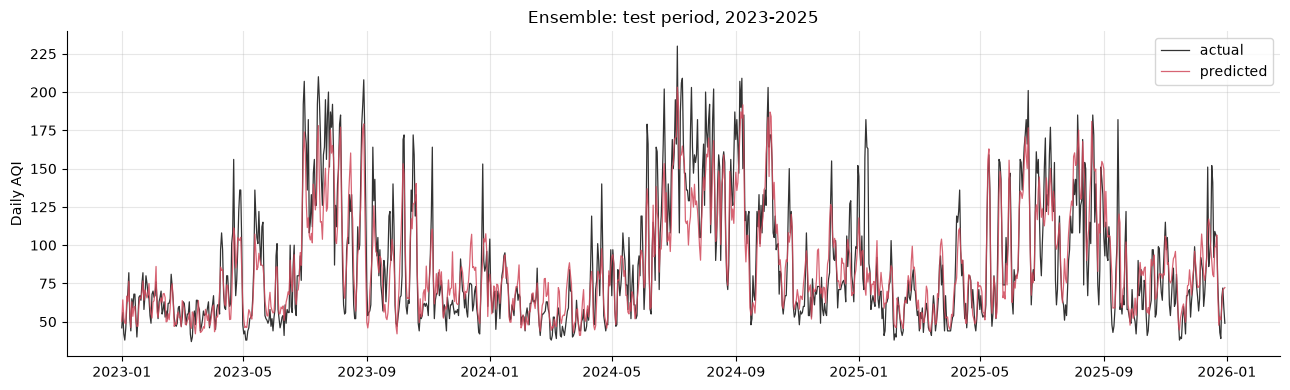

In [8]:
diagnostic_plots(MODEL_NAME, y_test, best.predict(X_test), meta['test_dates'])

## Where the gain comes from

The headline number improves, but it matters *which* days got better. If the ensemble only
helped on easy days it would be far less interesting than if it closed some of the gap on
the extreme days every individual model struggles with.

In [9]:
ens = best.predict(X_test)
yt = np.asarray(y_test, dtype=float)

BANDS = [(0, 50, 'Good 0-50'), (50, 100, 'Moderate 51-100'),
         (100, 150, 'USG 101-150'), (150, 300, 'Unhealthy 151+')]

rows = []
for lo, hi, label in BANDS:
    m = (yt > lo) & (yt <= hi)
    row = {'band': label, 'n': int(m.sum())}
    for n in BUILDERS:
        row[n] = np.mean(np.abs(yt[m] - base_test_pred[n][m]))
    row['Ensemble'] = np.mean(np.abs(yt[m] - ens[m]))
    row['best single'] = min(row[n] for n in BUILDERS)
    row['gain'] = row['best single'] - row['Ensemble']
    rows.append(row)

band = pd.DataFrame(rows)
print('Mean absolute error by band (AQI points):')
print(band.round(2).to_string(index=False))

wins = np.abs(yt - ens) < np.min([np.abs(yt - base_test_pred[n]) for n in BUILDERS], axis=0)
print(f'\ndays where the ensemble beats every single member: {wins.sum()} of {len(yt)} '
      f'({wins.mean():.1%})')

Mean absolute error by band (AQI points):
           band   n   SVR   MLP   GBR  Ensemble  best single  gain
      Good 0-50 123  9.55  9.14  8.77      7.48         8.77  1.29
Moderate 51-100 655  9.85 11.24  9.85      9.47         9.85  0.38
    USG 101-150 195 17.06 16.46 18.72     17.26        16.46 -0.80
 Unhealthy 151+ 122 31.97 29.70 32.61     30.27        29.70 -0.57

days where the ensemble beats every single member: 160 of 1095 (14.6%)


## What this told us

**Test RMSE 18.34, R² 0.794 — the best of any model in this project**, and the improvement
over SVR alone (18.85) is statistically robust rather than a coin flip.

The size of the gain is modest, about 3%. Its *reliability* is the more valuable part.
Choosing SVR meant betting on a 0.2-point difference whose confidence interval straddled
zero — betting on noise. The ensemble sidesteps that decision entirely by not making it.
If next year's data would have flipped the ranking between SVR and the MLP, the ensemble is
largely unaffected, and that robustness is worth more than the RMSE points.

It also costs almost nothing: no new tuning, no new features, no new data. The only real
price is operational — three models to fit and maintain instead of one, and prediction now
requires all three plus the meta-model.

Two findings worth carrying forward:

1. **Learned weights beat equal weights, but barely.** The ridge stack found SVR 0.31 /
   MLP 0.25 / GBR 0.48 and gained 0.145 RMSE over a plain average. Real, but small enough
   that on a smaller dataset the equal average would be the safer default — it has no
   parameters to estimate and cannot overfit the blend.
2. **The gain is concentrated in the middle of the distribution, not the tails.** On the
   122 unhealthy days the ensemble does not beat the best individual member. All three
   members miss those days for the same reason, so averaging cannot rescue them. Extreme-day
   performance needs a different intervention — asymmetric loss, quantile regression, or an
   external smoke indicator — not a better blend.